In [1]:
#import common library/function

import google.auth
import google.auth.impersonated_credentials
from concurrent.futures import TimeoutError
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.cloud import bigquery

/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
client = bigquery.Client(project="ingka-pmp-fixa-dev")


/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


## Queries collection

In [20]:
##sec 1: Overall task distribution type
code=""" 
SELECT
  task_type,
  FORMAT_DATE('%Y-%m', DATE(created_local_dt)) AS year_month,
  COUNT(DISTINCT task_id) AS distinct_task,
FROM
  `ingka-pmp-fixa-prod.report_fixa.task_overview`
WHERE
  created_local_dt BETWEEN '2024-09-01'
  AND '2026-02-28' AND store_no = '274'
GROUP BY
  1,
  2
"""

job=client.query(code)

task_overview=job.to_dataframe()

E0000 00:00:1772663966.102513  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [4]:
##sec 2.1: Overall task null distribution
code=""" 
SELECT
  COUNT(DISTINCT task_id) AS distinct_task,
  COUNT(DISTINCT
  IF
    (item_no IS NULL,task_id,NULL) ) AS task_id_item_null,
  COUNT(DISTINCT
  IF
    (item_name IS NULL,task_id,NULL) ) AS task_id_item_name_null,
  COUNT(DISTINCT
  IF
    (item_family_name IS NULL,task_id,NULL) ) AS task_id_item_family_name_null,
  COUNT(DISTINCT
  IF
    (item_pa_no IS NULL,task_id,NULL) ) AS task_id_pa_no_null,
  COUNT(DISTINCT
  IF
    (item_pa_name IS NULL,task_id,NULL) ) AS task_id_pa_name_null,
  COUNT(DISTINCT
  IF
    (item_pra_no IS NULL,task_id,NULL) ) AS task_id_pra_no_null,
  COUNT(DISTINCT
  IF
    (item_pra_name IS NULL,task_id,NULL) ) AS task_id_pra_name_null,
  COUNT(DISTINCT
  IF
    (item_hfb_no IS NULL,task_id,NULL) ) AS task_id_item_hfb_no_null,
  COUNT(DISTINCT
  IF
    (item_hfb_name IS NULL,task_id,NULL) ) AS task_id_item_hfb_name_null,
  COUNT(DISTINCT
  IF
    (item_hfb_no_name IS NULL,task_id,NULL) ) AS task_id_item_hfb_no_name_null,
  COUNT(DISTINCT
  IF
    (item_type IS NULL,task_id,NULL) ) AS task_item_type_null,
  COUNT(DISTINCT
  IF
    (item_name IS NULL,task_id,NULL) ) AS task_item_name_null,
  COUNT(DISTINCT
  IF
    (item_home_location_grid_code IS NULL,task_id,NULL) ) AS task_item_home_location_grid_code_null
FROM
  `ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks`
WHERE
  1=1
  AND DATE(created_utc_dttm) BETWEEN '2024-09-01'
  AND '2025-07-31'
  AND store_no = '274'

"""

job=client.query(code)

task_null_validation=job.to_dataframe()

E0000 00:00:1772663035.348885  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [5]:
#sec 2.2: Loading distribution location by refill

code=""" 
select --item_hfb_name, 
item_fill_location_department_name,
       count(distinct item_fill_location_grid_code) as number_of_different_grid_code
from ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks
where 1=1
      and date(created_local_dt) between '2024-09-01' and '2025-08-31'
     -- and item_hfb_name is not null
      AND store_no = '274'
group by item_fill_location_department_name
"""

job=client.query(code)

item_refill_location=job.to_dataframe()

E0000 00:00:1772663047.510539  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [70]:
#sec 2.2: Loading distribution location by refill by month

code=""" 
select 
    FORMAT_DATE('%Y-%m', created_local_dt) AS year_month,
item_fill_location_department_name,
       count(distinct item_fill_location_grid_code) as number_of_different_grid_code
from `ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks`
where 1=1
      and date(created_local_dt) between '2023-09-01' and '2026-02-28'
      AND store_no = '274'
group by 1,2
order by 1,2
"""

job=client.query(code)

item_refill_location_month=job.to_dataframe()

E0000 00:00:1772695481.988023  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [64]:
#sec 2.3.0: Loading number of task with refilled qty

##sec 2.3.1: Loading difference request vs refilled

#sec 2.3.2: Loading difference betweek picked vs refilled 

## sec 2.3.3 : Overall task distribution type


code=""" 
SELECT  
    DATE(created_utc_dttm) AS task_created_date,
    FORMAT_DATE('%Y-%m', DATE(created_utc_dttm)) AS year_month,
    task_id,
    store_no_name,
    item_no,
    item_name,
    item_price_eur,
    filled_qty,  
    requested_qty, 
    refilled_qty,
    picked_qty,
    requested_qty - refilled_qty AS difference_requested_refilled,
    picked_qty - refilled_qty AS difference_picked_refilled
FROM ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks
WHERE 1=1
    AND  ((DATE(created_utc_dttm) BETWEEN '2024-09-01' AND '2024-09-30') OR 
    (DATE(created_utc_dttm) BETWEEN '2025-09-01' AND '2025-09-30'))
    AND fill_type = 'REGULAR'
    AND fill_home_flag = FALSE
    AND completed_local_dt IS NOT NULL
    AND filled_qty IS NOT NULL
    AND refilled_qty IS NOT NULL
    AND picked_qty IS NOT NULL
     AND store_no = '274'
"""
job=client.query(code)

addons_refill_difference=job.to_dataframe()

E0000 00:00:1772694872.387121  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [ ]:

#sec 2.4 Code time between test
code=""" 
select task_id, 
       difference_in_seconds
from(
select task_id,
       store_no_name,
       created_local_dt,  
       row_number() over(order by created_local_dt) as order_survey, 
       lag(created_local_dt) over(order by created_local_dt) as previous_timestamp, 
       timestamp_diff(created_local_dt,lag(created_local_dt) over(order by created_local_dt),SECOND) as difference_in_seconds, 
       case when lag(date(created_local_dt)) over(order by date(created_local_dt))!=date(created_local_dt) then 1 else 0 end as flag
from ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks
where 1=1
      and date(created_local_dt) between '2024-09-01' and '2025-07-31'
     -- and store_no='501'
order by created_local_dt)
where 1=1
      and flag=0
      and difference_in_seconds is not null
"""

job=client.query(code)

addons_time_between_tasks=job.to_dataframe()

In [10]:
#sec 2.4 Loading the time completed task


code=""" 
      select lag_created_completed_minute
      from ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks
      where 1=1
            and date(created_utc_dttm) between '2024-09-01' and '2025-07-31'
            
            --and fill_type='REGULAR'
            --and refill_home_flag=false
            and completed_local_dt is not null
            --and refilled_qty is not null
                 AND store_no = '274'

"""

job=client.query(code)

created_completed_June24=job.to_dataframe()

E0000 00:00:1772663715.613125  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [11]:
##sec 2.5.1 : Overall validation length grid code =6
code=""" 
SELECT
  FORMAT_DATE('%Y-%m', DATE(created_local_dt)) AS year_month,
  COUNT(DISTINCT
  IF
    (LENGTH(item_fill_location_grid_code) !=6, item_fill_location_grid_code,NULL)) AS incorrect_grid_length,
  COUNT(DISTINCT
  IF
    (LENGTH(item_fill_location_grid_code) =6, item_fill_location_grid_code,NULL)) AS correct_grid_length,
  COUNT(DISTINCT item_fill_location_grid_code) AS total_distinc_grid,
  COUNT(DISTINCT
  IF
    (LENGTH(item_fill_location_grid_code) !=6, item_fill_location_grid_code,NULL))/COUNT(DISTINCT item_fill_location_grid_code) AS perc_incorrect_grid_length,
  COUNT(DISTINCT
  IF
    (LENGTH(item_fill_location_grid_code) =6, item_fill_location_grid_code,NULL))/COUNT(DISTINCT item_fill_location_grid_code) AS perc_correct_grid_length,
FROM
  `ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks`
WHERE
  1=1
  AND DATE(created_local_dt) BETWEEN '2023-09-01'
  AND '2025-11-30'
  and item_fill_location_department_no ='OT'
       AND store_no = '274'

GROUP BY
  1
ORDER BY
  1 asc

"""

job=client.query(code)

task_grid_validation=job.to_dataframe()


E0000 00:00:1772663725.561108  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [86]:
##sec 2.5.2 : loading validation grid code
code=""" 
WITH
  filtered_data AS (
  SELECT
    cal.ikea_week_no,
    cal.iso_month_no,
    fixa.store_no,
    fixa.store_no_name,
    fixa.item_no,
    fixa.item_fill_location_grid_code,
    DATE(fixa.created_utc_dttm) AS create_date
  FROM
    `ingka-pmp-fixa-prod.report_fixa.addon_insight_completed_tasks` fixa
  LEFT JOIN
       `ingka-sbpdp-ecbd-prod.dm_calendar_ref_no_pii.calendar_dim_v` cal
  ON
    DATE(fixa.created_utc_dttm) = cal.day_date
  WHERE
    1=1
    -- AND store_no = '274'
    AND DATE(created_utc_dttm) >= '2023-09-01' AND DATE(created_utc_dttm) <= '2026-02-28' ),
  -- Get data from SLM to join for assigned sale_space_quantity
  slm_data AS (
  SELECT
    article_id,
    bu_code,
    sales_location_id,
    CASE
      WHEN location_type = '1' THEN 'H'
      WHEN location_type = '2' THEN 'P'
      ELSE ' '
  END
    AS location_type_derived,
    location_type,
    assigned_sales_space_quantity,
    PARSE_DATE('%Y%m%d', from_date) AS from_date,
    # nex import_date is the until_date with the condition of row_numb = 1
    import_date as till_date,
    active,
ROW_NUMBER() OVER (PARTITION BY article_id, bu_code, sales_location_id, from_date
ORDER BY CAST(import_date AS DATE) DESC) AS row_num
  FROM
    `ingka-cff-slm-prod.slm.article_location_weekly`
  WHERE
    import_date >= '2023-09-01'
     --    AND store_no = '274'
 Qualify row_num = 1 ),
  unique_store_location_set AS (
  SELECT
    DISTINCT fd.ikea_week_no,
    fd.iso_month_no,
    fd.store_no,
    fd.store_no_name,
    fd.item_fill_location_grid_code,
    CASE
      WHEN fd.item_fill_location_grid_code = slm.sales_location_id THEN 1
      WHEN  slm.sales_location_id is null THEN 0
      ELSE 0
  END
    AS valid_grid_code,
    slm.location_type
  FROM
    filtered_data AS fd
  LEFT JOIN
    slm_data AS slm
  ON
    1=1
    AND slm.article_id = fd.item_no
    AND fd.item_fill_location_grid_code = slm.sales_location_id
    AND fd.create_date >= slm.from_date
    AND (fd.create_date <= slm.till_date      )
    AND fd.store_no = slm.bu_code 
    AND ( slm.location_type = '0'
        OR slm.location_type  is null)
    )
SELECT
  ikea_week_no,
  iso_month_no,
  store_no,
  store_no_name,
  COUNT(*) AS total_grid_codes,
  SUM(valid_grid_code) AS total_valid_grid_codes
FROM
  unique_store_location_set
WHERE store_no = '274'
GROUP BY
  ikea_week_no,
  store_no,
  store_no_name, 
  iso_month_no

"""

job=client.query(code)

task_location=job.to_dataframe()

E0000 00:00:1772696538.958499  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [14]:
##sec 2.5.3 : Data validation SLM
code=""" 
select article_id, bu_code, sales_location_id, from_date, import_date, location_type from (
SELECT
    article_id,
    bu_code,
    sales_location_id,
    CASE
      WHEN location_type = '1' THEN 'H'
      WHEN location_type = '2' THEN 'P'
      WHEN location_type = '3' THEN 'HP'
      WHEN location_type = '0' THEN 'N'
      ELSE ' '
  END
    AS location_type_derived,
    location_type,
    assigned_sales_space_quantity,
    PARSE_DATE('%Y%m%d', from_date) AS from_date,
    import_date ,
    active
  FROM
    `ingka-cff-slm-prod.slm.article_location_weekly`
  WHERE
    bu_code = '274' and
    import_date >= '2025-03-01' and import_date <= '2025-03-31'
)


"""

job=client.query(code)

check_location_id=job.to_dataframe()

E0000 00:00:1772663885.360796  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [16]:
##sec 2.5.3.1 Data validation slm 2
code=""" 
WITH
  count_unique_loc AS(
  SELECT
    article_id,
    bu_code,
    sales_location_id,
    import_date,
    COUNT(DISTINCT location_type) AS daily_unique_location_type
  FROM (
    SELECT
      article_id,
      bu_code,
      sales_location_id,
      location_type,
      assigned_sales_space_quantity,
      PARSE_DATE('%Y%m%d', from_date) AS from_date,
      # nex import_date is the until_date with the condition of row_numb = 1
      import_date,
      active,
      ROW_NUMBER() OVER (PARTITION BY article_id, bu_code, sales_location_id ORDER BY CAST(import_date AS DATE) DESC) AS row_num
    FROM
      `ingka-cff-slm-prod.slm.article_location_weekly`
    WHERE
      -- bu_code = '087'
      -- AND
      import_date >= '2025-03-01'
      AND import_date <= '2025-03-31'
      --Qualify row_num = 1
      )
  GROUP BY
    article_id,
    bu_code,
    sales_location_id,
    import_date )
SELECT
  bu_code,
  SUM(CASE
      WHEN daily_unique_location_type = 1 THEN 1
      ELSE 0
  END
    ) AS oneloc,
  SUM(CASE
      WHEN daily_unique_location_type != 1 THEN 1
      ELSE 0
  END
    ) AS gt1loc,
  100*SUM(CASE
      WHEN daily_unique_location_type != 1 THEN 1
      ELSE 0
  END
    )/SUM(CASE
      WHEN daily_unique_location_type = 1 THEN 1
      ELSE 0
  END
    ) AS perc
FROM
  count_unique_loc
  where bu_code = '274'
GROUP BY
  1


"""

job=client.query(code)

check_uniq_location_type=job.to_dataframe()

E0000 00:00:1772663924.425895  838068 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


# Section 1 : Overall task distribution

In [21]:
grouped_month=task_overview.groupby(['year_month']).agg({
           'distinct_task' : ['sum']
        }).reset_index()


grouped_month.columns = grouped_month.columns.map('_'.join)
grouped_month.rename(columns = {
                                'year_month_' : 'year_month',
                      'distinct_task_sum' : 'distinct_task_tot'
                         }, inplace = True)
grouped_month.head()

,year_month,distinct_task_tot
0,2024-09,2025
1,2024-10,2129
2,2024-11,2128
3,2024-12,2056
4,2025-01,1835


In [22]:
merged = pd.merge(task_overview, grouped_month, on=[ 'year_month'], how= 'left')

merged['ratio'] = 100.*merged['distinct_task']/merged['distinct_task_tot']

merged.head()

,task_type,year_month,distinct_task,distinct_task_tot,ratio
0,ADDON,2025-03,1988,2094,94.937918
1,ADDON,2025-07,2374,2405,98.711019
2,ADDON,2025-04,1981,2044,96.917808
3,TESTBUY_FOLLOW_UP,2025-06,53,2239,2.367128
4,ROOM_SETTINGS,2025-08,90,2994,3.006012


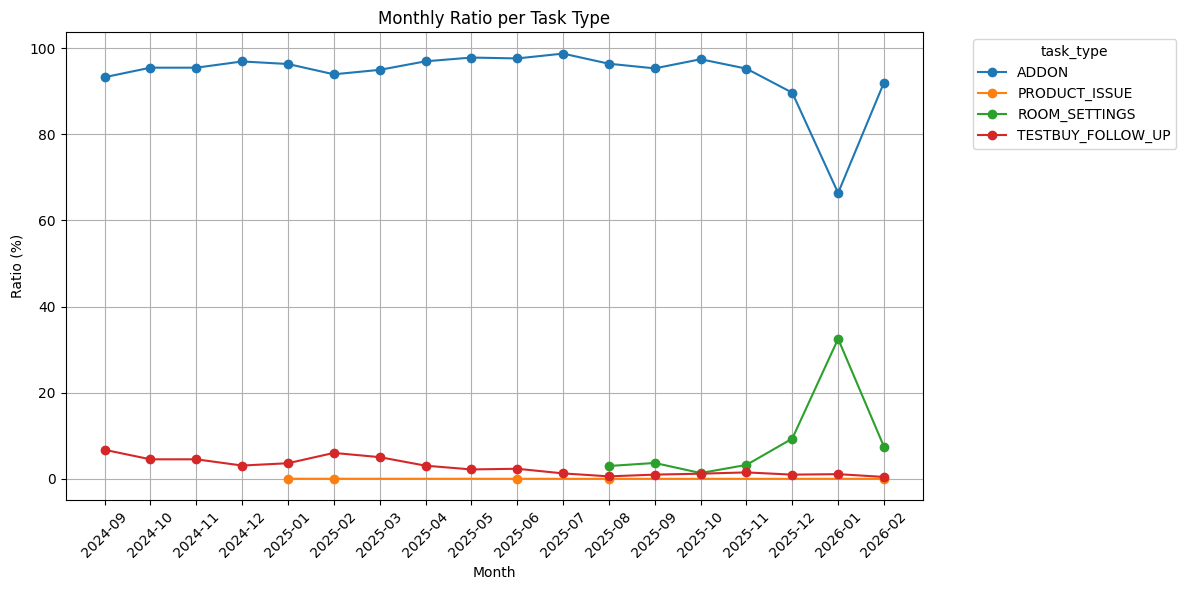

In [23]:
# Sort for proper chronological plotting
df_sorted = merged.sort_values("year_month").copy()

# Choose the categorical column to distinguish colours
CATEGORY_COL = "task_type"           # change to "merged_task" if needed

# --- Plot one line per CATEGORY_COL ---
plt.figure(figsize=(12, 6))
palette = sns.color_palette("tab10", n_colors=df_sorted[CATEGORY_COL].nunique())

for (cat_value, subdf), color in zip(df_sorted.groupby(CATEGORY_COL), palette):
    plt.plot(
        subdf["year_month"],
        subdf["ratio"],
        marker="o",
        linestyle="-",
        color=color,
        label=str(cat_value),
    )

plt.title("Monthly Ratio per Task Type")
plt.xlabel("Month")
plt.ylabel("Ratio (%)")
plt.grid(True)
plt.legend(title=CATEGORY_COL, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Section 2 : Overall validation


## 2.1 null distribution 


In [24]:
task_null_validation

,distinct_task,task_id_item_null,task_id_item_name_null,task_id_item_family_name_null,task_id_pa_no_null,task_id_pa_name_null,task_id_pra_no_null,task_id_pra_name_null,task_id_item_hfb_no_null,task_id_item_hfb_name_null,task_id_item_hfb_no_name_null,task_item_type_null,task_item_name_null,task_item_home_location_grid_code_null
0,22539,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2.2 Overall distribution location by refill


In [25]:
item_refill_location.head()

,item_fill_location_department_name,number_of_different_grid_code
0,Self-serve furniture area,36
1,Children's IKEA,24
2,Store and organise furniture,23
3,Cooking,18
4,Eating,20


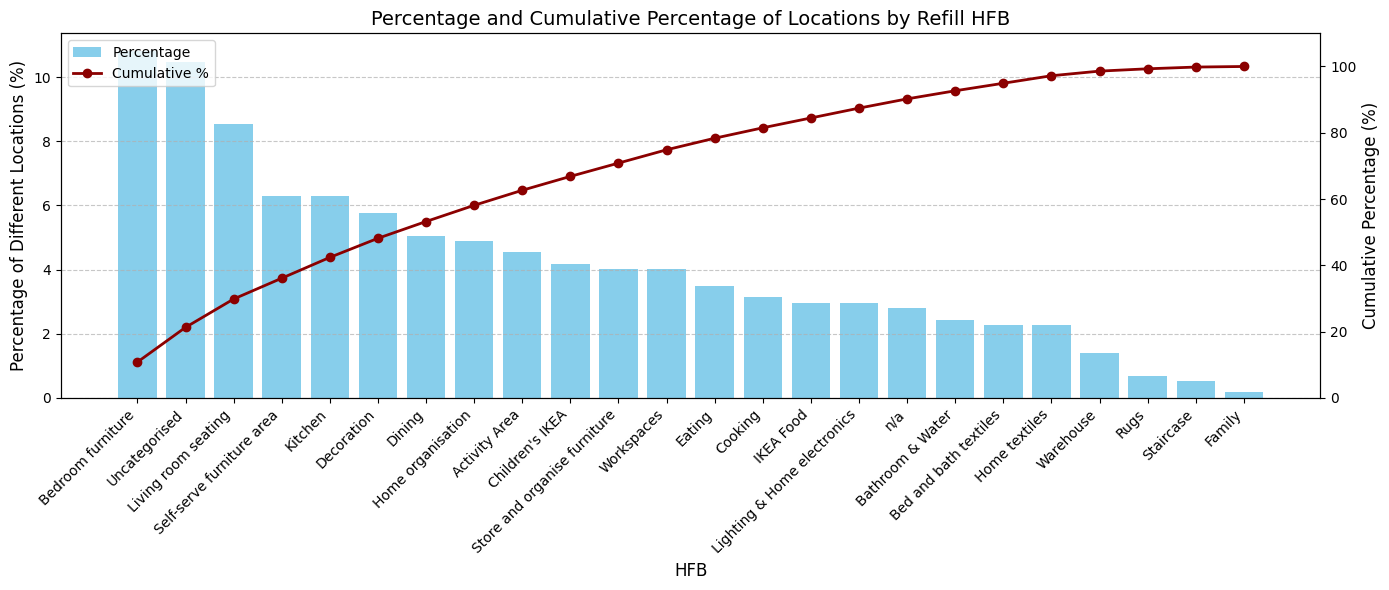

In [26]:
# Calculate total and percentage
total = item_refill_location['number_of_different_grid_code'].sum()
item_refill_location['percentage'] = (
    item_refill_location['number_of_different_grid_code'] / total
) * 100

# Sort by percentage in descending order
df_plot = item_refill_location.sort_values('percentage', ascending=False).reset_index(drop=True)

# Compute cumulative percentage
df_plot['cumulative_percentage'] = df_plot['percentage'].cumsum()

# Create figure and bar chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart (left axis)
bars = ax1.bar(
    df_plot['item_fill_location_department_name'],
    df_plot['percentage'],
    color='skyblue',
    label='Percentage'
)

# Customize X-axis
ax1.set_xticks(range(len(df_plot)))
ax1.set_xticklabels(df_plot['item_fill_location_department_name'], rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Percentage of Different Locations (%)', fontsize=12)
ax1.set_xlabel('HFB', fontsize=12)
ax1.set_title('Percentage and Cumulative Percentage of Locations by Refill HFB', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Create second Y-axis for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(
    df_plot['cumulative_percentage'],
    color='darkred',
    marker='o',
    linewidth=2,
    label='Cumulative %'
)
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax2.set_ylim(0, 110)  # Make room for 100%+

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Final layout
plt.tight_layout()
plt.show()

In [71]:
item_refill_location_month.loc[(item_refill_location_month.year_month >='2024-09') & 
    (item_refill_location_month.year_month <'2025-09') & 
    (item_refill_location_month.item_fill_location_department_name	=='Uncategorised')].number_of_different_grid_code.sum()/item_refill_location_month.loc[(item_refill_location_month.year_month >='2024-09') & 
    (item_refill_location_month.year_month <'2025-09') ].number_of_different_grid_code.sum()

0.10718294051627385

            total_grid_codes  uncat_grid_codes  pct_uncat
year_month                                               
2023-09-01               227                25  11.013216
2023-10-01               264                26   9.848485
2023-11-01               253                23   9.090909
2023-12-01               232                27  11.637931
2024-01-01               233                32  13.733906
2024-02-01               239                28  11.715481
2024-03-01               284                34  11.971831
2024-04-01               300                46  15.333333
2024-05-01               315                40  12.698413
2024-06-01               277                46  16.606498
2024-07-01               282                40  14.184397
2024-08-01               274                43  15.693431
2024-09-01               268                48  17.910448
2024-10-01               284                44  15.492958
2024-11-01               308                48  15.584416
2024-12-01    

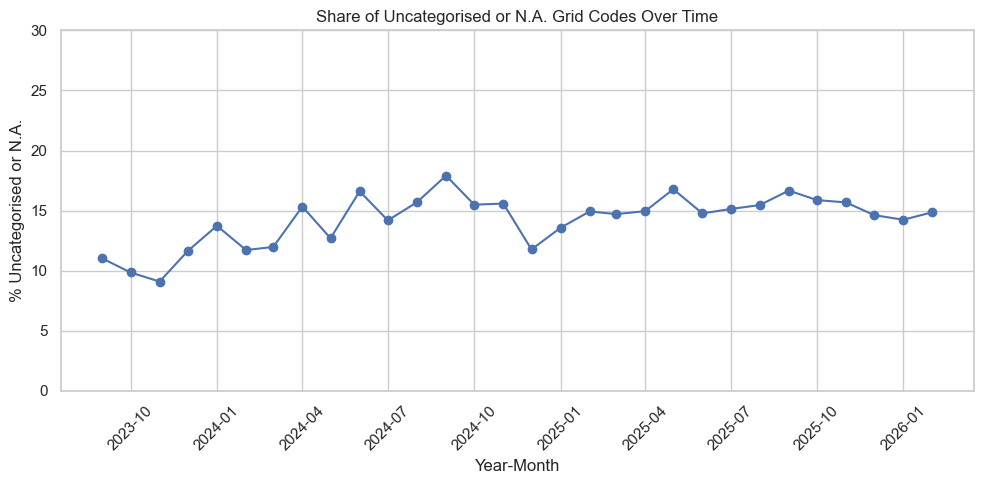

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure year_month is a proper period or datetime (optional but useful for plotting) ---
df = item_refill_location_month.copy()
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y-%m')

# --- Total per month ---
total_per_month = (
    df.groupby('year_month')['number_of_different_grid_code']
      .sum()
      .rename('total_grid_codes')
)

# --- Uncategorised / n.a per month ---
mask_uncat = df['item_fill_location_department_name'].str.strip().str.casefold().isin(
    ['uncategorised', 'n/a']
)

uncat_per_month = (
    df[mask_uncat]
      .groupby('year_month')['number_of_different_grid_code']
      .sum()
      .rename('uncat_grid_codes')
)

# --- Combine and compute percentage ---
summary = (
    pd.concat([total_per_month, uncat_per_month], axis=1)
      .fillna({'uncat_grid_codes': 0})  # if some months have no uncategorised/n.a.
)

summary['pct_uncat'] = summary['uncat_grid_codes'] / summary['total_grid_codes'] * 100

print(summary)

# --- Plot evolution ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(summary.index, summary['pct_uncat'], marker='o')
ax.set_xlabel('Year-Month')
ax.set_ylabel('% Uncategorised or N.A.')
ax.set_title('Share of Uncategorised or N.A. Grid Codes Over Time')
ax.grid(True)
ax.set_ylim(0, 30)  # <-- y-axis between 30 and 50
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [29]:
item_refill_location

,item_fill_location_department_name,number_of_different_grid_code,percentage
0,Self-serve furniture area,36,6.282723
1,Children's IKEA,24,4.188482
2,Store and organise furniture,23,4.013962
3,Cooking,18,3.141361
4,Eating,20,3.490401
5,Home organisation,28,4.886562
6,Activity Area,26,4.537522
7,Decoration,33,5.759162
8,n/a,16,2.792321
9,Home textiles,13,2.268761


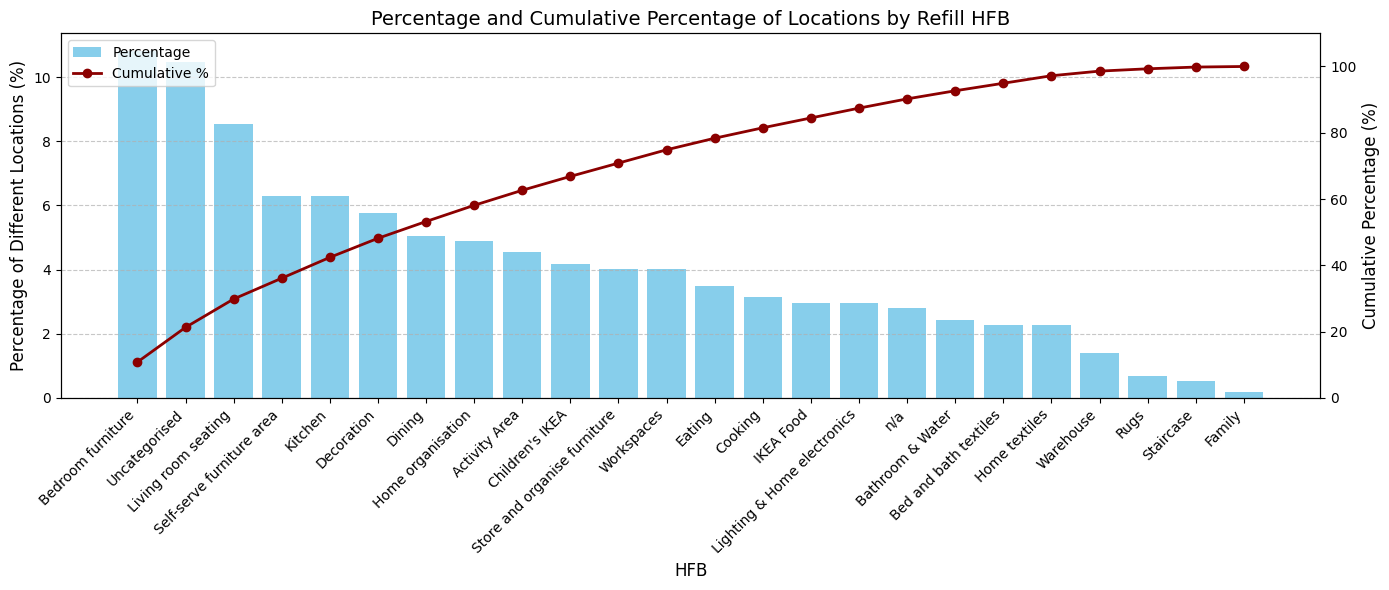

In [30]:
# Calculate total and percentage
total = item_refill_location['number_of_different_grid_code'].sum()
item_refill_location['percentage'] = (
    item_refill_location['number_of_different_grid_code'] / total
) * 100

# Sort by percentage in descending order
df_plot = item_refill_location.sort_values('percentage', ascending=False).reset_index(drop=True)

# Compute cumulative percentage
df_plot['cumulative_percentage'] = df_plot['percentage'].cumsum()

# Create figure and bar chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart (left axis)
bars = ax1.bar(
    df_plot['item_fill_location_department_name'],
    df_plot['percentage'],
    color='skyblue',
    label='Percentage'
)

# Customize X-axis
ax1.set_xticks(range(len(df_plot)))
ax1.set_xticklabels(df_plot['item_fill_location_department_name'], rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Percentage of Different Locations (%)', fontsize=12)
ax1.set_xlabel('HFB', fontsize=12)
ax1.set_title('Percentage and Cumulative Percentage of Locations by Refill HFB', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Create second Y-axis for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(
    df_plot['cumulative_percentage'],
    color='darkred',
    marker='o',
    linewidth=2,
    label='Cumulative %'
)
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax2.set_ylim(0, 110)  # Make room for 100%+

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Final layout
plt.tight_layout()
plt.show()

## Section 2.3  Min max validation distribution


### 2.3.0 Number of task with refill value quantity


In [68]:
addons_refill_difference.head()

,task_created_date,year_month,task_id,store_no_name,item_no,item_name,item_price_eur,filled_qty,requested_qty,refilled_qty,picked_qty,difference_requested_refilled,difference_picked_refilled
0,2025-09-08,2025-09,d2a6b1c0-4bcb-44e4-a73f-3b9710b786d8,274 - IKEA Barendrecht,50594150,JÄMLIK scntd cndl in glss 12 hr Vanilla/lbeige,0.590000000,74.000000000,74.000000000,74.000000000,74.000000000,0E-9,0E-9
1,2025-09-08,2025-09,a5e84358-4ffb-4765-9ff4-7eed9a1e4865,274 - IKEA Barendrecht,90474443,STUK box w comp 34x51x18 white,6.990000000,35.000000000,35.000000000,35.000000000,35.000000000,0E-9,0E-9
2,2025-09-08,2025-09,c8e7c6e7-68f2-4361-93bf-0f3abf8fa23f,274 - IKEA Barendrecht,90554538,VISSLAÅN box w lid s5 grey,9.990000000,96.000000000,96.000000000,96.000000000,96.000000000,0E-9,0E-9
3,2025-09-06,2025-09,1a10e562-9bf0-450a-9634-55c90a9dac6c,274 - IKEA Barendrecht,90554538,VISSLAÅN box w lid s5 grey,9.990000000,21.000000000,21.000000000,21.000000000,21.000000000,0E-9,0E-9
4,2025-09-06,2025-09,742f1e6b-12a4-4e27-a77c-a485ba209f38,274 - IKEA Barendrecht,87077700,HEAT pot stand 19 cork 3-p,1.990000000,55.000000000,55.000000000,55.000000000,55.000000000,0E-9,0E-9


/var/folders/69/q_vmc6ns6_v503hjpfz65h8r0000gp/T/ipykernel_9423/3288320707.py:88: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


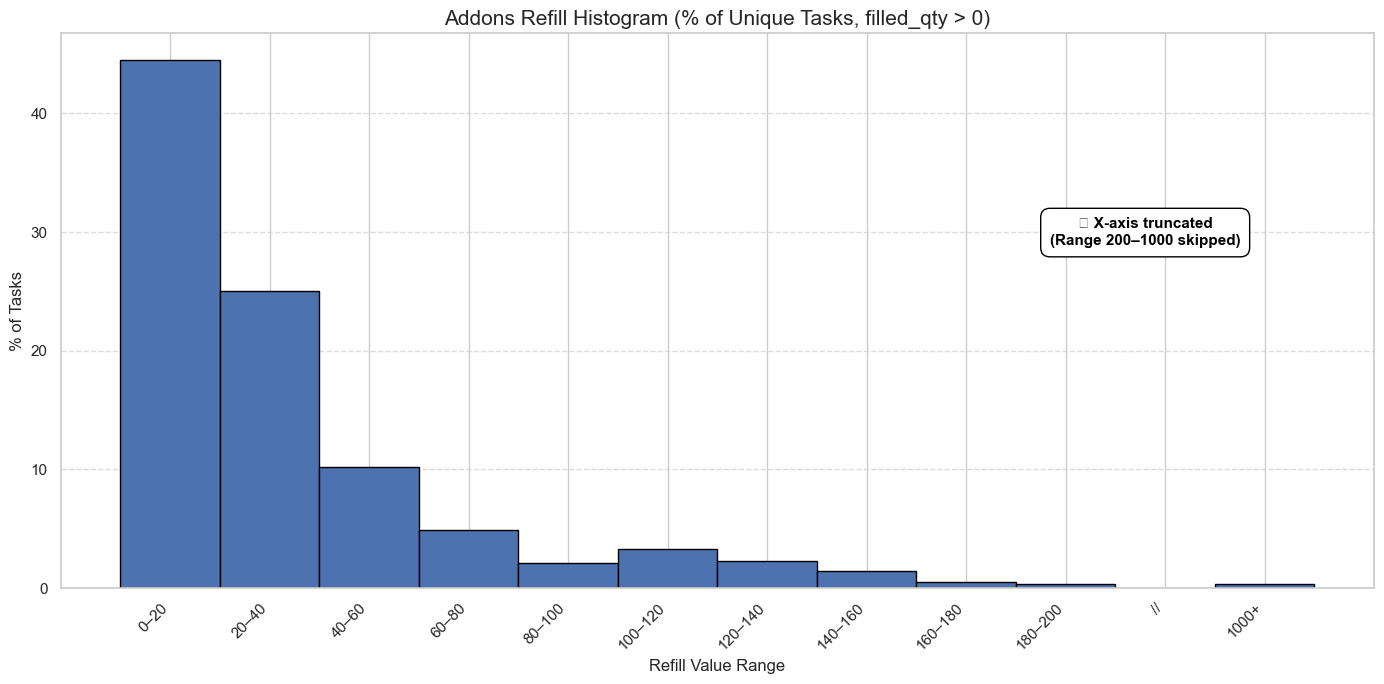

In [69]:
# Define bin edges: 0 to 1000 in steps of 20, then an overflow bin
bin_edges = np.append(np.arange(0, 1000, 20), [np.inf])

# Clean data: remove nulls, duplicates, and filled_qty == 0
df = (
    addons_refill_difference[['task_id', 'filled_qty']]
    .dropna()
    .drop_duplicates()
)
df = df[df['filled_qty'] > 0]

# Convert to float to avoid Decimal issues
data = df['filled_qty'].astype(float)

# Histogram with overflow bin
counts, bins = np.histogram(data, bins=bin_edges)
percentages = counts / counts.sum() * 100

# Generate bin labels
bin_labels = [f"{int(bins[i])}–{int(bins[i+1])}" if bins[i+1] != np.inf else "1000+" for i in range(len(bins)-1)]

# Show only first 10 bins (0–200) + break + overflow
num_bins_to_show = 10
bin_labels_to_show = bin_labels[:num_bins_to_show] + ['//', bin_labels[-1]]
percentages_to_show = list(percentages[:num_bins_to_show]) + [0, percentages[-1]]  # 0 for the break bar

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(bin_labels_to_show, percentages_to_show, width=1, edgecolor='black', align='center')

# Make break bar invisible
bars[num_bins_to_show].set_color('white')
bars[num_bins_to_show].set_edgecolor('white')

# Add visible "X-axis truncated" label
plt.text(
    num_bins_to_show - 0.2,
    max(percentages_to_show) * 0.65,
    '⚠ X-axis truncated\n(Range 200–1000 skipped)',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='black',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Rotate X-axis labels
plt.xticks(rotation=45, ha='right')

# Compute statistics
min_val = data.min()
max_val = data.max()
mean_val = data.mean()
median_val = data.median()
std_val = data.std()

# Outlier detection with IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outliers = data[data > outlier_threshold]
num_outliers = len(outliers)
outlier_pct = num_outliers / len(data) * 100

# Add statistics box (more spacious and aligned)
stats_text = (
    f" Stats:\n"
    f"• Min: {min_val:.0f}    Max: {max_val:.0f}\n"
    f"• Mean: {mean_val:.1f}    Median: {median_val:.1f}\n"
    f"• Std Dev: {std_val:.1f}\n"
    f"• Outliers (> {outlier_threshold:.0f}): {num_outliers} ({outlier_pct:.1f}%)"
)
#plt.text(
  #  0.98, 0.95, stats_text,
   # transform=plt.gca().transAxes,
  #  fontsize=11,
  #  verticalalignment='top',
  #  horizontalalignment='right',
 #   bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
#)

# Titles and final styling
plt.title('Addons Refill Histogram (% of Unique Tasks, filled_qty > 0)', fontsize=15)
plt.xlabel('Refill Value Range', fontsize=12)
plt.ylabel('% of Tasks', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/var/folders/69/q_vmc6ns6_v503hjpfz65h8r0000gp/T/ipykernel_9423/4202967591.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (task_qty.groupby(["year_month", "bin"])


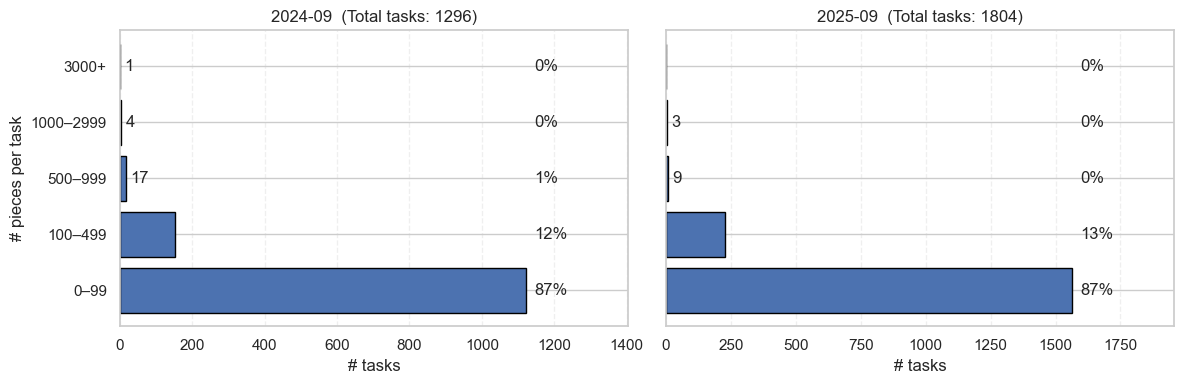

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

m1, m2 = "2024-09", "2025-09"

df = addons_refill_difference.copy()
df["year_month"] = df["year_month"].astype(str)

df = df[df["year_month"].isin([m1, m2])]
df = df[["year_month", "task_id", "filled_qty"]].dropna()
df["filled_qty"] = df["filled_qty"].astype(float)
df = df[df["filled_qty"] > 0]

task_qty = df.groupby(["year_month", "task_id"], as_index=False)["filled_qty"].sum()

bins   = [0, 100, 500, 1000, 3000, np.inf]
labels = ["0–99", "100–499", "500–999", "1000–2999", "3000+"]

task_qty["bin"] = pd.cut(task_qty["filled_qty"], bins=bins, labels=labels, right=False)

summary = (task_qty.groupby(["year_month", "bin"])
                  .size()
                  .reset_index(name="tasks"))

tot = summary.groupby("year_month")["tasks"].sum().rename("total_tasks")
summary = summary.merge(tot, on="year_month")
summary["pct"] = 100 * summary["tasks"] / summary["total_tasks"]

summary = (summary.set_index(["year_month", "bin"])
                  .reindex(pd.MultiIndex.from_product([[m1, m2], labels], names=["year_month","bin"]))
                  .fillna(0)
                  .reset_index())

# bins where you want to show counts close to the bar
show_count_bins = {"500–999", "1000–2999", "3000+"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, month in zip(axes, [m1, m2]):
    s = summary[summary["year_month"] == month].copy()
    s["bin"] = pd.Categorical(s["bin"], categories=labels, ordered=True)
    s = s.sort_values("bin", ascending=True)

    ax.barh(s["bin"], s["tasks"], edgecolor="black")
    ax.set_title(f"{month}  (Total tasks: {int(s['total_tasks'].max())})")
    ax.set_xlabel("# tasks")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    xmax = s["tasks"].max() if s["tasks"].max() > 0 else 1

    for b, tasks, pct in zip(s["bin"], s["tasks"], s["pct"]):
        b = str(b)

        # % on the far right
        ax.text(xmax * 1.02, b, f"{pct:.0f}%", va="center", ha="left")

        # count near the bar for big-scale bins
        if b in show_count_bins and tasks > 0:
            ax.text(tasks + xmax * 0.01, b, f"{int(tasks):,}", va="center", ha="left")

    ax.set_xlim(0, xmax * 1.25)

axes[0].set_ylabel("# pieces per task")
plt.tight_layout()
plt.show()


### 2.3.1 Refill qty and requested difference 

/var/folders/69/q_vmc6ns6_v503hjpfz65h8r0000gp/T/ipykernel_9423/3399100411.py:93: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


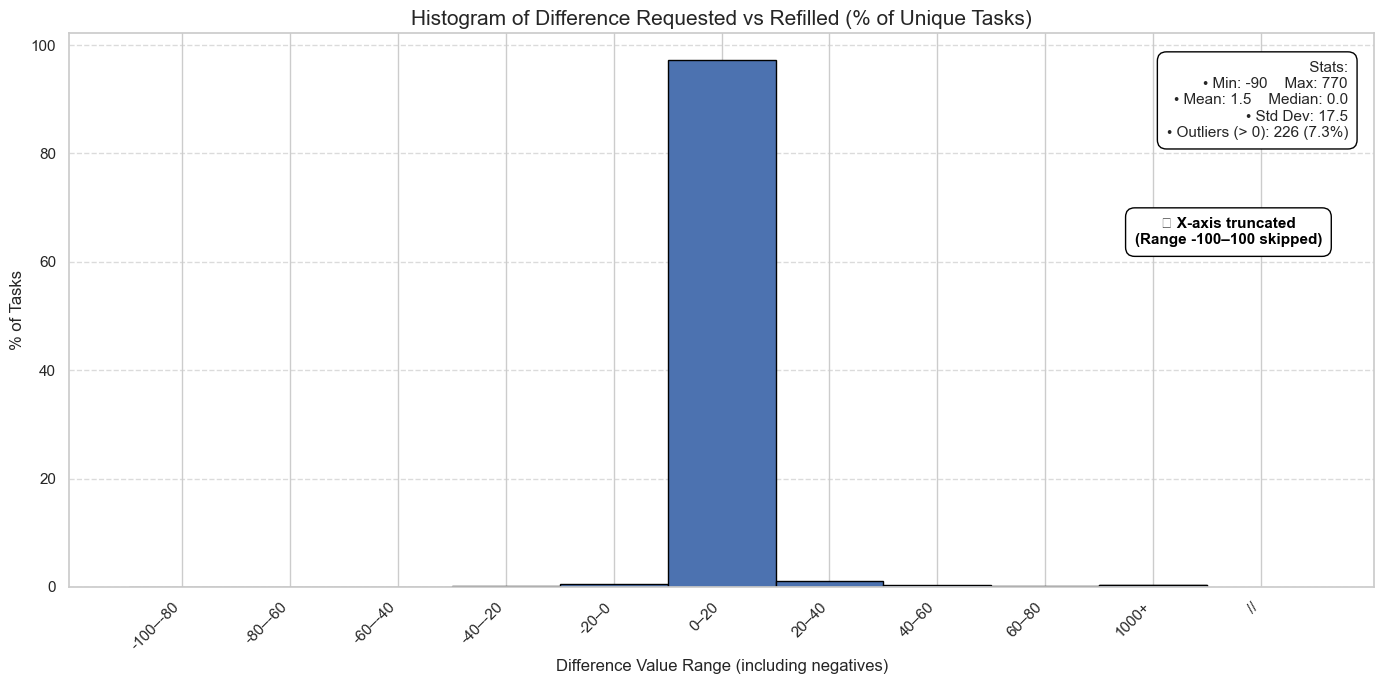

In [74]:
# Define bin edges: from -500 to 1000 in steps of 20, then overflow
bin_edges = np.append(np.arange(-100, 100, 20), [np.inf])

# Clean data: remove nulls, duplicates only
df = (
    addons_refill_difference[['task_id', 'difference_requested_refilled']]
    .dropna()
    .drop_duplicates()
)

# Convert to float (for Decimal safety)
data = df['difference_requested_refilled'].astype(float)

# Histogram
counts, bins = np.histogram(data, bins=bin_edges)
percentages = counts / counts.sum() * 100

# Create bin labels
bin_labels = [
    f"{int(bins[i])}–{int(bins[i+1])}" if bins[i+1] != np.inf else "1000+"
    for i in range(len(bins) - 1)
]

# Determine indices to show before truncation (up to 200) and final bin (1000+)
cutoff_index = np.where(bins >= 200)[0][0]  # first bin starting at >= 200
overflow_index = len(bin_labels) - 1        # last bin (1000+)

# Compose labels and data to show (truncate middle)
bin_labels_to_show = bin_labels[:cutoff_index] + ['//'] + [bin_labels[overflow_index]]
percentages_to_show = list(percentages[:cutoff_index]) + [0] + [percentages[overflow_index]]

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(bin_labels_to_show, percentages_to_show, width=1, edgecolor='black', align='center')

# Make break bar invisible
bars[cutoff_index].set_color('white')
bars[cutoff_index].set_edgecolor('white')

# Add visible truncation label
plt.text(
    cutoff_index - 0.3,
    max(percentages_to_show) * 0.65,
    '⚠ X-axis truncated\n(Range -100–100 skipped)',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='black',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Rotate X-axis labels
plt.xticks(rotation=45, ha='right')

# Compute statistics
min_val = data.min()
max_val = data.max()
mean_val = data.mean()
median_val = data.median()
std_val = data.std()

# Outlier detection (IQR on absolute values)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outliers = data[data > outlier_threshold]
num_outliers = len(outliers)
outlier_pct = num_outliers / len(data) * 100

# Stats box
stats_text = (
    f" Stats:\n"
    f"• Min: {min_val:.0f}    Max: {max_val:.0f}\n"
    f"• Mean: {mean_val:.1f}    Median: {median_val:.1f}\n"
    f"• Std Dev: {std_val:.1f}\n"
    f"• Outliers (> {outlier_threshold:.0f}): {num_outliers} ({outlier_pct:.1f}%)"
)
plt.text(
    0.98, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Final formatting
plt.title('Histogram of Difference Requested vs Refilled (% of Unique Tasks)', fontsize=15)
plt.xlabel('Difference Value Range (including negatives)', fontsize=12)
plt.ylabel('% of Tasks', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [75]:
addons_refill_difference[['task_id', 'difference_requested_refilled']].min()

task_id                          0006a6d5-7d16-4bfe-8e4d-b904f5772af4
difference_requested_refilled                           -90.000000000
dtype: object

### 2.3.2 Picked qty and refill difference

/var/folders/69/q_vmc6ns6_v503hjpfz65h8r0000gp/T/ipykernel_9423/2855094536.py:93: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


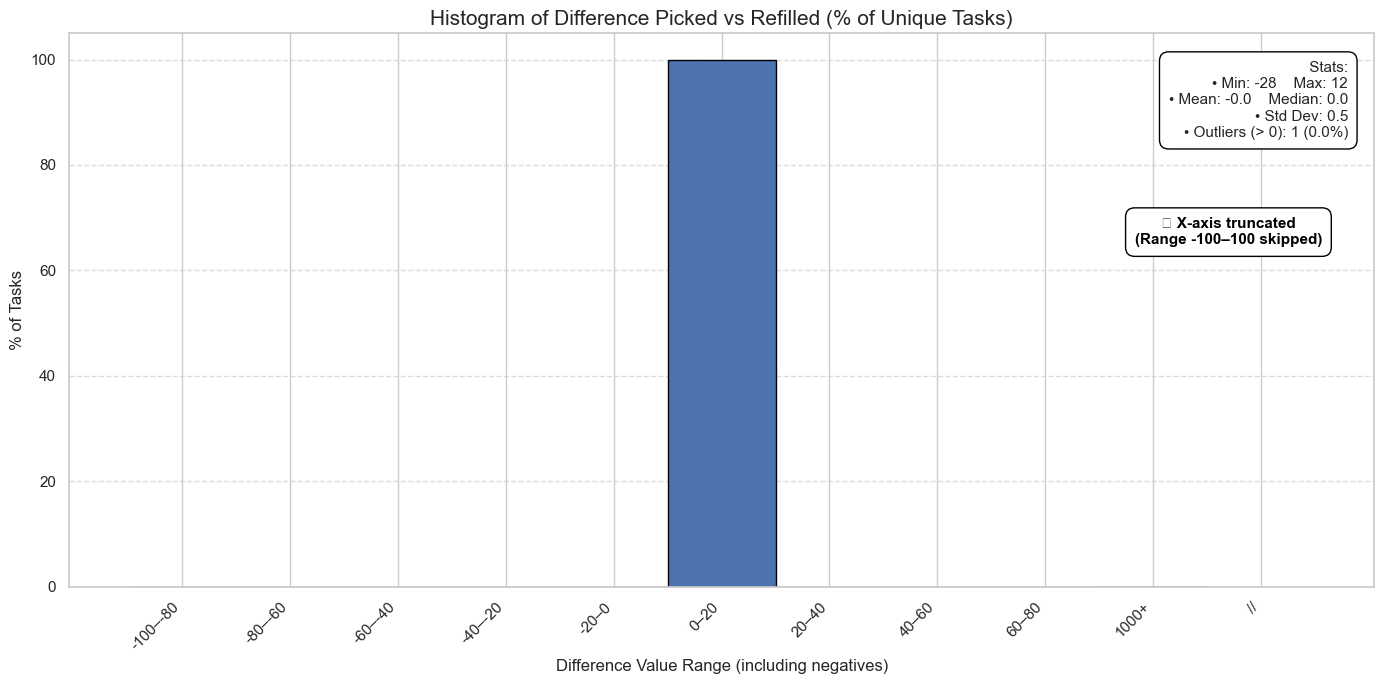

In [76]:
# Define bin edges: from -500 to 1000 in steps of 20, then overflow
bin_edges = np.append(np.arange(-100, 100, 20), [np.inf])

# Clean data: remove nulls, duplicates only
df = (
    addons_refill_difference[['task_id', 'difference_picked_refilled']]
    .dropna()
    .drop_duplicates()
)

# Convert to float (for Decimal safety)
data = df['difference_picked_refilled'].astype(float)

# Histogram
counts, bins = np.histogram(data, bins=bin_edges)
percentages = counts / counts.sum() * 100

# Create bin labels
bin_labels = [
    f"{int(bins[i])}–{int(bins[i+1])}" if bins[i+1] != np.inf else "1000+"
    for i in range(len(bins) - 1)
]

# Determine indices to show before truncation (up to 200) and final bin (1000+)
cutoff_index = np.where(bins >= 200)[0][0]  # first bin starting at >= 200
overflow_index = len(bin_labels) - 1        # last bin (1000+)

# Compose labels and data to show (truncate middle)
bin_labels_to_show = bin_labels[:cutoff_index] + ['//'] + [bin_labels[overflow_index]]
percentages_to_show = list(percentages[:cutoff_index]) + [0] + [percentages[overflow_index]]

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(bin_labels_to_show, percentages_to_show, width=1, edgecolor='black', align='center')

# Make break bar invisible
bars[cutoff_index].set_color('white')
bars[cutoff_index].set_edgecolor('white')

# Add visible truncation label
plt.text(
    cutoff_index - 0.3,
    max(percentages_to_show) * 0.65,
    '⚠ X-axis truncated\n(Range -100–100 skipped)',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='black',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Rotate X-axis labels
plt.xticks(rotation=45, ha='right')

# Compute statistics
min_val = data.min()
max_val = data.max()
mean_val = data.mean()
median_val = data.median()
std_val = data.std()

# Outlier detection (IQR on absolute values)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outliers = data[data > outlier_threshold]
num_outliers = len(outliers)
outlier_pct = num_outliers / len(data) * 100

# Stats box
stats_text = (
    f" Stats:\n"
    f"• Min: {min_val:.0f}    Max: {max_val:.0f}\n"
    f"• Mean: {mean_val:.1f}    Median: {median_val:.1f}\n"
    f"• Std Dev: {std_val:.1f}\n"
    f"• Outliers (> {outlier_threshold:.0f}): {num_outliers} ({outlier_pct:.1f}%)"
)
plt.text(
    0.98, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Final formatting
plt.title('Histogram of Difference Picked vs Refilled (% of Unique Tasks)', fontsize=15)
plt.xlabel('Difference Value Range (including negatives)', fontsize=12)
plt.ylabel('% of Tasks', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2.3.3 Min max distribution

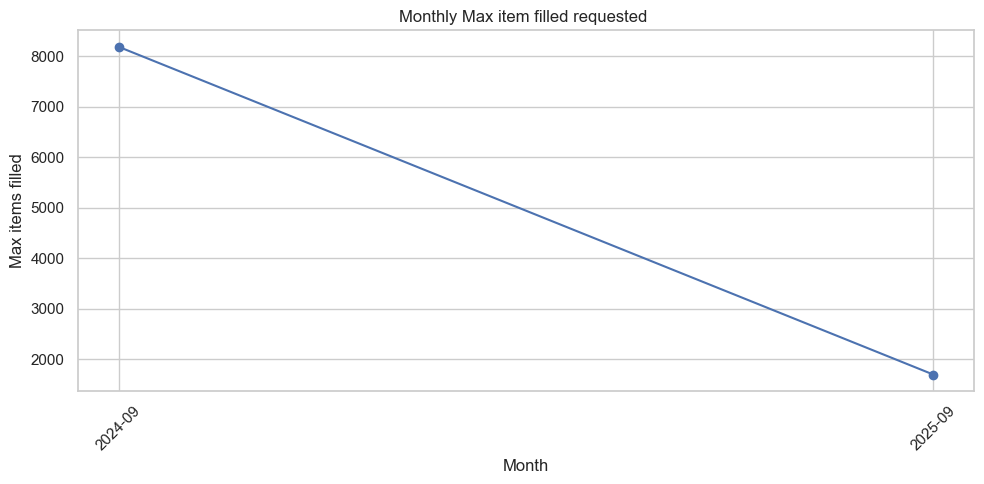

In [77]:
#trend with the max mothly requested
grouped_month_max=addons_refill_difference.groupby(['year_month']).agg({
           'requested_qty' : ['max'],
        }).reset_index()



grouped_month_max.columns = grouped_month_max.columns.map('_'.join)
grouped_month_max.rename(columns = {
                                'year_month_' : 'year_month',
                      'requested_qty_max_' : 'requested_qty_max'
                         }, inplace = True)



# Ordena por fecha por si acaso
grouped_month_max = grouped_month_max.sort_values('year_month')

grouped_month_max['year_month']=grouped_month_max['year_month'].astype(str)
# Plot
plt.figure(figsize=(10, 5))
plt.plot(grouped_month_max['year_month'], grouped_month_max['requested_qty_max'], marker='o', linestyle='-')
plt.title('Monthly Max item filled requested ')
plt.xlabel('Month')
plt.ylabel('Max items filled')

#plt.ylim(90, 100)  

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

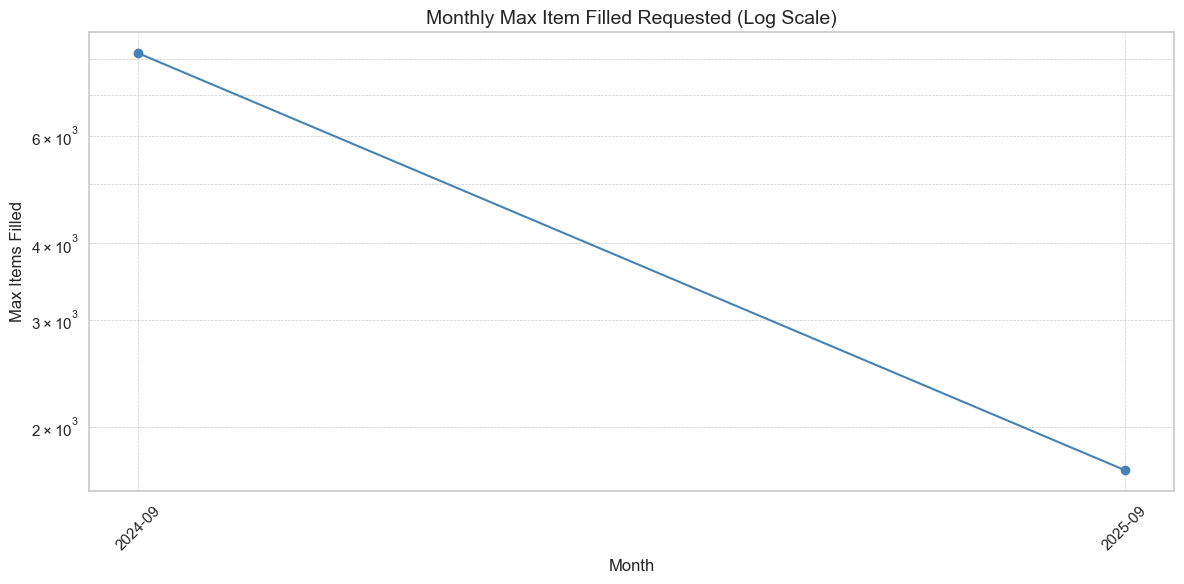

In [78]:
import matplotlib.pyplot as plt

# Ordenar por fecha por si acaso
grouped_month_max = grouped_month_max.sort_values('year_month')
grouped_month_max['year_month'] = grouped_month_max['year_month'].astype(str)

# Crear la figura
plt.figure(figsize=(12, 6))
plt.plot(
    grouped_month_max['year_month'],
    grouped_month_max['requested_qty_max'],
    marker='o', linestyle='-', color='steelblue'
)

# Título y etiquetas
plt.title('Monthly Max Item Filled Requested (Log Scale)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Max Items Filled', fontsize=12)

# Escala logarítmica en el eje Y
plt.yscale('log')

# Ajustes estéticos
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [40]:
grouped_month_max.tail()

NameError: name 'grouped_month_max' is not defined

In [79]:
addons_refill_difference.loc[(addons_refill_difference.year_month=='2025-08') & 
                             (addons_refill_difference.requested_qty > 10000)
                            ]

,task_created_date,year_month,task_id,store_no_name,item_no,item_name,item_price_eur,filled_qty,requested_qty,refilled_qty,picked_qty,difference_requested_refilled,difference_picked_refilled


In [80]:
addons_refill_difference

,task_created_date,year_month,task_id,store_no_name,item_no,item_name,item_price_eur,filled_qty,requested_qty,refilled_qty,picked_qty,difference_requested_refilled,difference_picked_refilled
0,2025-09-08,2025-09,d2a6b1c0-4bcb-44e4-a73f-3b9710b786d8,274 - IKEA Barendrecht,50594150,JÄMLIK scntd cndl in glss 12 hr Vanilla/lbeige,0.590000000,74.000000000,74.000000000,74.000000000,74.000000000,0E-9,0E-9
1,2025-09-08,2025-09,a5e84358-4ffb-4765-9ff4-7eed9a1e4865,274 - IKEA Barendrecht,90474443,STUK box w comp 34x51x18 white,6.990000000,35.000000000,35.000000000,35.000000000,35.000000000,0E-9,0E-9
2,2025-09-08,2025-09,c8e7c6e7-68f2-4361-93bf-0f3abf8fa23f,274 - IKEA Barendrecht,90554538,VISSLAÅN box w lid s5 grey,9.990000000,96.000000000,96.000000000,96.000000000,96.000000000,0E-9,0E-9
3,2025-09-06,2025-09,1a10e562-9bf0-450a-9634-55c90a9dac6c,274 - IKEA Barendrecht,90554538,VISSLAÅN box w lid s5 grey,9.990000000,21.000000000,21.000000000,21.000000000,21.000000000,0E-9,0E-9
4,2025-09-06,2025-09,742f1e6b-12a4-4e27-a77c-a485ba209f38,274 - IKEA Barendrecht,87077700,HEAT pot stand 19 cork 3-p,1.990000000,55.000000000,55.000000000,55.000000000,55.000000000,0E-9,0E-9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3095,2025-09-18,2025-09,b19aabc6-60cd-4b9a-a090-846c2d98ac7b,274 - IKEA Barendrecht,70591179,BJÖRKGRÅMAL dc/pwc 140x200/60x70 blk whi/dotted,17.990000000,5.000000000,5.000000000,5.000000000,5.000000000,0E-9,0E-9
3096,2024-09-25,2024-09,LtRQHUOApz2GtqhAkVgW,274 - IKEA Barendrecht,50546951,CYMBALBLOMMA dc/pwc 140x200/60x70 white/blue,5.990000000,5.000000000,5.000000000,5.000000000,5.000000000,0E-9,0E-9
3097,2024-09-25,2024-09,h6ABrDoVNmlsmHk3H0P7,274 - IKEA Barendrecht,80328145,FRYKEN box w lid s3 seagrass,12.990000000,5.000000000,5.000000000,5.000000000,5.000000000,0E-9,0E-9
3098,2025-09-16,2025-09,c8abf480-8631-44a4-8583-d94f90cfe007,274 - IKEA Barendrecht,30357159,DVALA N fitt sheet 140x200 beige,8.990000000,5.000000000,5.000000000,5.000000000,5.000000000,0E-9,0E-9


In [81]:
grouped_month_gt3000

NameError: name 'grouped_month_gt3000' is not defined

  year_month  item_no_count_ge3000  item_no_count_total  pct_ge3000
0    2024-09                     1                 1296     0.07716


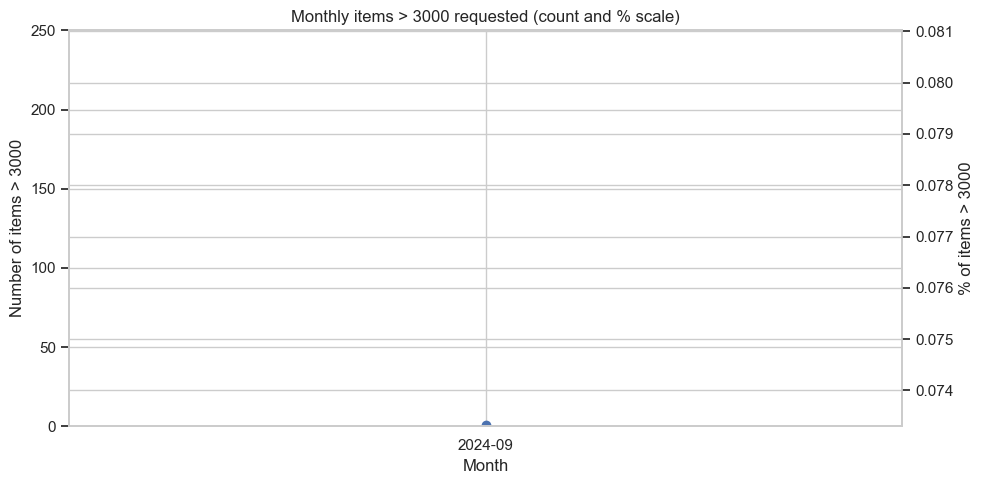

In [82]:
import matplotlib.pyplot as plt

# ---- 1) Items >= 3000 per month ----
grouped_month_gt3000 = (
    addons_refill_difference
    .loc[addons_refill_difference.requested_qty >= 3000]
    .groupby(['year_month'])
    .agg({'item_no': ['count']})
    .reset_index()
)

grouped_month_gt3000.columns = grouped_month_gt3000.columns.map('_'.join)
grouped_month_gt3000.rename(columns={
    'year_month_': 'year_month',
    'item_no_count': 'item_no_count_ge3000'
}, inplace=True)

# ---- 2) Total items per month (for the %) ----
grouped_month_total = (
    addons_refill_difference
    .groupby(['year_month'])
    .agg({'item_no': ['count']})
    .reset_index()
)

grouped_month_total.columns = grouped_month_total.columns.map('_'.join)
grouped_month_total.rename(columns={
    'year_month_': 'year_month',
    'item_no_count': 'item_no_count_total'
}, inplace=True)

# ---- 3) Merge and compute percentage (0–100) ----
df_plot = grouped_month_gt3000.merge(grouped_month_total, on='year_month', how='left')
df_plot = df_plot.sort_values('year_month')
df_plot['year_month'] = df_plot['year_month'].astype(str)

df_plot['pct_ge3000'] = (
    df_plot['item_no_count_ge3000'] / df_plot['item_no_count_total'] * 100.0
)

# (optional) quick sanity check
print(df_plot[['year_month', 'item_no_count_ge3000',
               'item_no_count_total', 'pct_ge3000']])

# ---- 4) Plot: left axis = count, right axis = % scale (no second line) ----
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left y-axis: number of items > 3000 (single line)
ax1.plot(
    df_plot['year_month'],
    df_plot['item_no_count_ge3000'],
    marker='o',
    linestyle='-'
)
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of items > 3000')
ax1.set_ylim(0, 250)
ax1.grid(True)

# Right y-axis: % of items > 3000 (scale only)
ax2 = ax1.twinx()
ax2.set_ylabel('% of items > 3000')

min_pct = df_plot['pct_ge3000'].min()
max_pct = df_plot['pct_ge3000'].max()
ax2.set_ylim(min_pct * 0.95, max_pct * 1.05)  # no 0.000 unless it's really 0

plt.xticks(rotation=45)
plt.title('Monthly items > 3000 requested (count and % scale)')
fig.tight_layout()
plt.show()


## 2.4 Time:  between test, completed task


In [83]:
addons_time_between_tasks

,task_id,difference_in_seconds
0,VzCrS9mItO6T3wF7Lg9z,3
1,TQfytRpVtA5yIJmQ646x,10
2,uCUzSDlzSOXADadjHGL9,13
3,Ef14qdTvRDN6TDFMxx70,17
4,6B09QLw44Cw6xoME7OCT,120
...,...,...
10129147,fe5b6ee4-b663-4b83-afe1-b21fc6da82ea,135
10129148,053f2722-1a59-4666-a7a4-5cf1c4bc979c,14
10129149,245af0b6-7494-4a5a-9edc-bcf39f8cae5b,10
10129150,131b7897-839f-4325-86fa-ef94239181e0,41


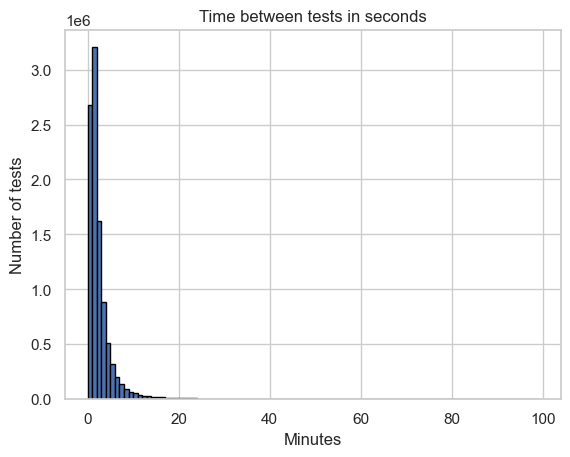

In [84]:
import matplotlib.pyplot as plt
import numpy as np

#Number of bins
bin_edges=np.arange(0,100,1)
# Crear el histograma
plt.hist(addons_time_between_tasks['difference_in_seconds'], bins=bin_edges, edgecolor='black')

# Añadir títulos y etiquetas
plt.title('Time between tests in seconds')
plt.xlabel('Minutes')
plt.ylabel('Number of tests')

# Mostrar el histograma
plt.show()

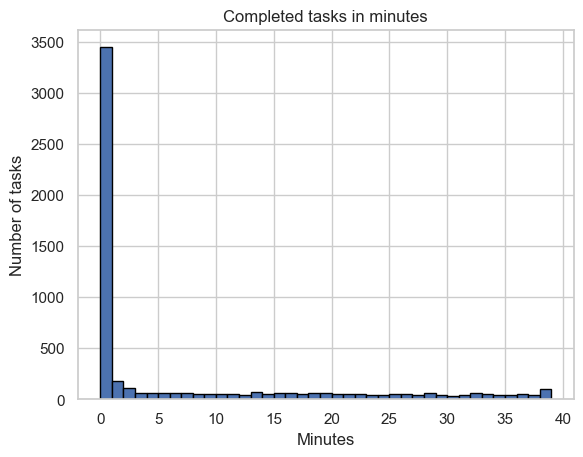

In [85]:
import matplotlib.pyplot as plt
import numpy as np

#Number of bins
bin_edges=np.arange(0,40,1)
# Crear el histograma
plt.hist(created_completed_June24['lag_created_completed_minute'], bins=bin_edges, edgecolor='black')

# Añadir títulos y etiquetas
plt.title('Completed tasks in minutes')
plt.xlabel('Minutes')
plt.ylabel('Number of tasks')

# Mostrar el histograma
plt.show()

## 2.5 Validation valid grid code

## 2.5.1 simple location validation

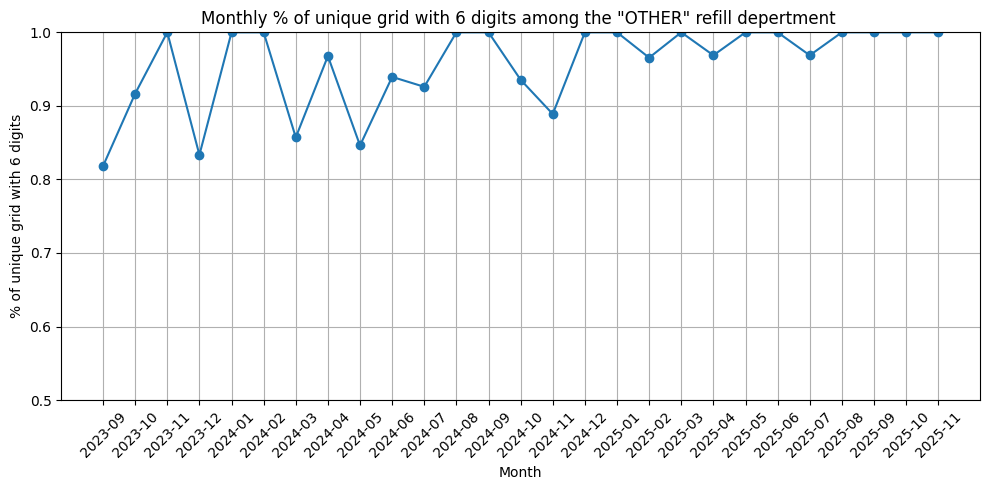

In [48]:
# Ordena por fecha por si acaso
task_grid_validation = task_grid_validation.sort_values('year_month')

task_grid_validation['year_month']=task_grid_validation['year_month'].astype(str)
# Plot
plt.figure(figsize=(10, 5))
plt.plot(task_grid_validation['year_month'], task_grid_validation['perc_correct_grid_length'], marker='o', linestyle='-')
plt.title('Monthly % of unique grid with 6 digits among the "OTHER" refill depertment ')
plt.xlabel('Month')
plt.ylabel('% of unique grid with 6 digits')

plt.ylim(0.5, 1.00)  

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.5.2 validation grid code

In [49]:
task_location.store_no.nunique()

1

In [87]:
grouped_month=task_location.groupby(['iso_month_no']).agg({
           'total_grid_codes' : ['sum'],
           'total_valid_grid_codes' : ['sum']
        }).reset_index()


grouped_month.columns = grouped_month.columns.map('_'.join)
grouped_month.rename(columns = {
                                'iso_month_no_' : 'iso_month_no',
                      'total_grid_codes_sum' : 'total_grid_codes',
                      'total_valid_grid_codes_sum' : 'total_valid_grid_codes'
                         }, inplace = True)
grouped_month['ratio_valid']= 100.*grouped_month['total_valid_grid_codes'] /grouped_month['total_grid_codes'] 
grouped_month.head()

,iso_month_no,total_grid_codes,total_valid_grid_codes,ratio_valid
0,202309,559,479,85.68873
1,202310,717,602,83.960948
2,202311,631,528,83.676704
3,202312,655,557,85.038168
4,202401,615,549,89.268293


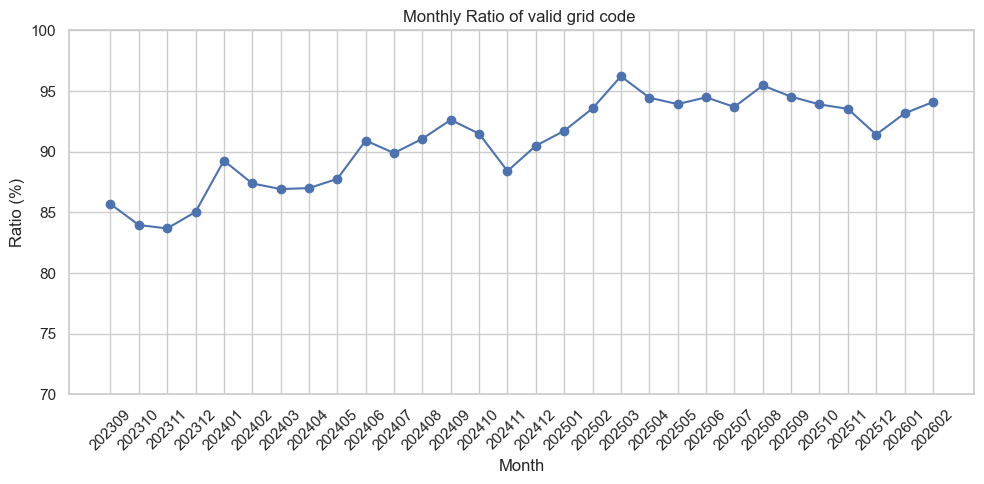

In [88]:

# Ordena por fecha por si acaso
grouped_month = grouped_month.sort_values('iso_month_no')

grouped_month['iso_month_no']=grouped_month['iso_month_no'].astype(str)
# Plot
plt.figure(figsize=(10, 5))
plt.plot(grouped_month['iso_month_no'], grouped_month['ratio_valid'], marker='o', linestyle='-')
plt.title('Monthly Ratio of valid grid code ')
plt.xlabel('Month')
plt.ylabel('Ratio (%)')

plt.ylim(70, 100)  

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()